# Titanic


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_raw_train = pd.read_csv('./data/train.csv')
titanic_raw_test = pd.read_csv('./data/test.csv')

titanic_raw_train['train_test'] = 1
titanic_raw_test['train_test'] = 0
titanic_raw_test['Survived'] = np.nan

titanic_combined_raw = pd.concat([titanic_raw_train, titanic_raw_test])

titanic_raw_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_test
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


### Exploratory Analysis
- Id, Ticket are random unique identifiers => exclude
- Unsure about Embarked as all of them happened before the iceberg
- Name and Pclass might allow relate to social status etc.
- Cabin may relate to position on ship, but contains many null values => exclude

In [3]:
titanic_raw_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [4]:
titanic_raw_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.0


In [5]:
def age_2_agegroup(x):
    if x < 10:
        return '0-10'
    elif x < 20:
        return '10-20'
    elif x < 30:
        return '20-30'
    elif x < 40:
        return '30-40'
    elif x < 50:
        return '40-50'
    elif x < 60:
        return '50-60'
    elif x < 70:
        return '60-70'
    elif x < 80:
        return '70-80'
    else:
        return '80+'
    
def fare_2_faregroup(x):
    if x < 50:
        return '0-50'
    elif x < 100:
        return '50-100'
    elif x < 150:
        return '100-150'
    elif x < 200:
        return '150-200'
    else:
        return '200+'
        


titanic_train = titanic_raw_train.round(0)
titanic_train['ageGroup'] = titanic_train['Age'].apply(lambda x: age_2_agegroup(x))
titanic_train['fareGroup'] = titanic_train['Fare'].apply(lambda x: fare_2_faregroup(x))

titanic_train['Cabin'] = titanic_train['Cabin'].fillna('-')
titanic_train['Cabin'] = titanic_train['Cabin'].apply(lambda x: x[0])
titanic_train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,train_test,ageGroup,fareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.0,-,S,1,20-30,0-50
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.0,C,C,1,30-40,50-100
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,8.0,-,S,1,20-30,0-50
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.0,C,S,1,30-40,50-100
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0,-,S,1,30-40,0-50


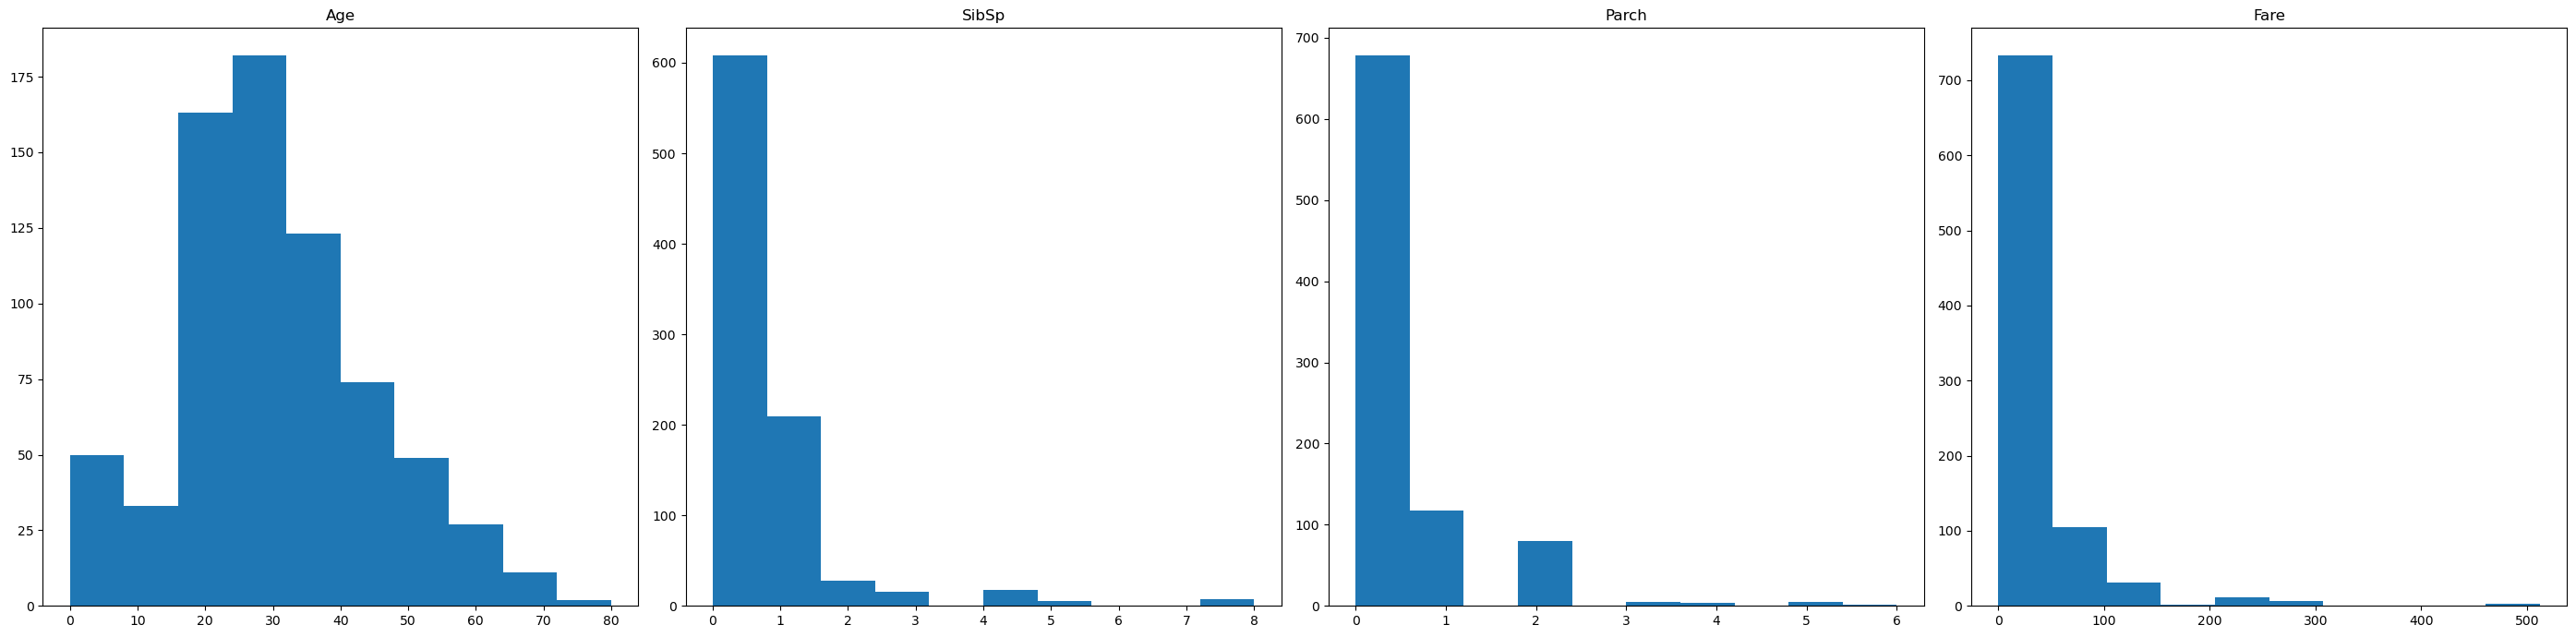

In [6]:
titanic_train_numerical = titanic_train[['Age','SibSp','Parch','Fare']]

fig, ax = plt.subplots(1, 4, figsize=(28, 7))
ax = ax.flatten()  
for idx, col in enumerate(titanic_train_numerical.columns):
    ax[idx].hist(titanic_train_numerical[col])
    ax[idx].set_title(col)

plt.tight_layout() 
plt.show()

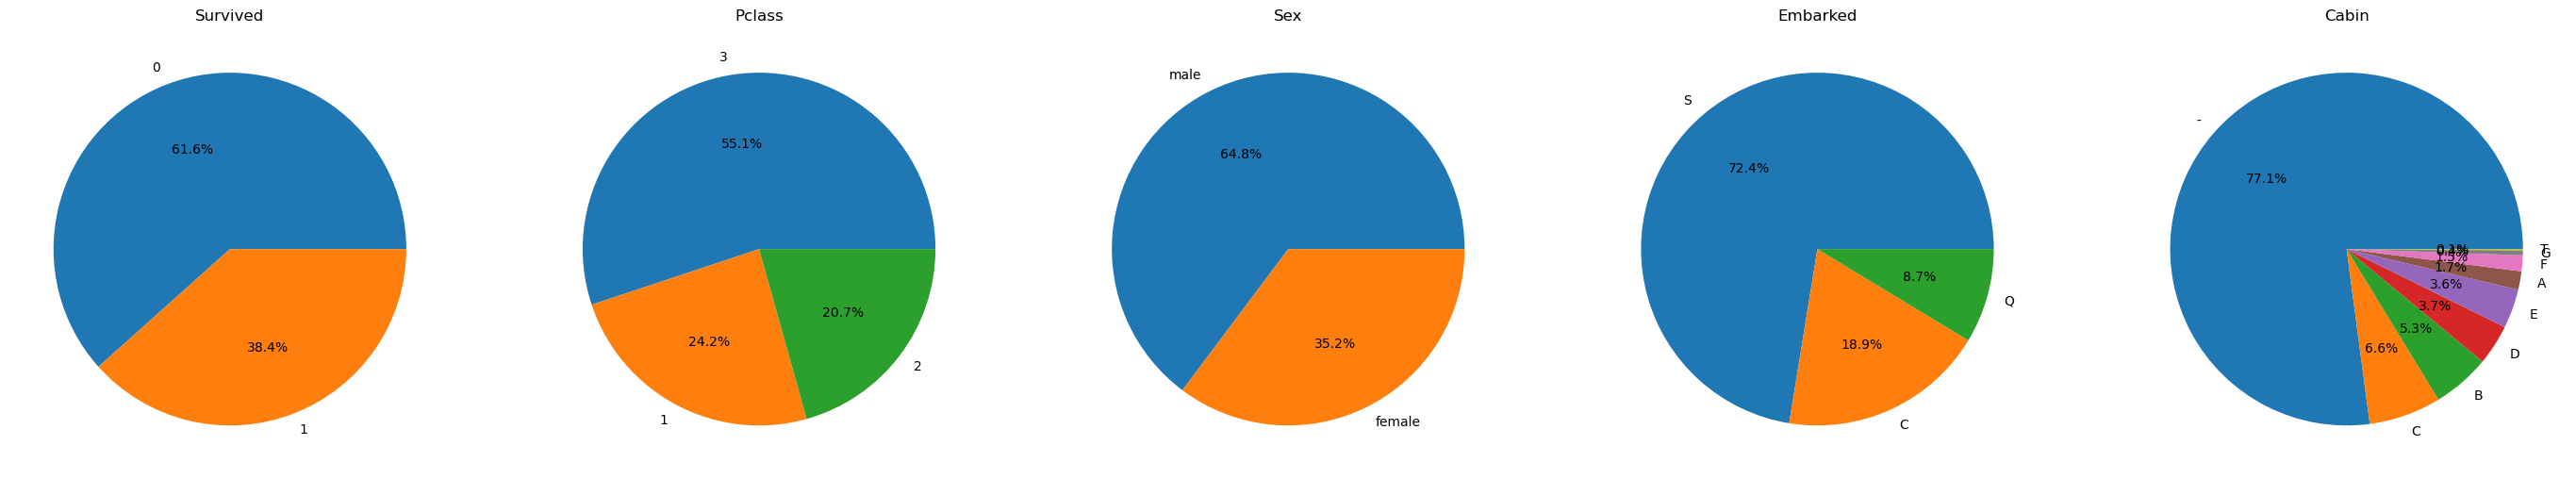

In [7]:
titanic_df_categorical = titanic_train[['Survived','Pclass','Sex','Embarked', 'Cabin']]

fig, ax = plt.subplots(1, 5, figsize=(35, 7))
ax = ax.flatten()
for idx, col in enumerate(titanic_df_categorical.columns):
    ax[idx].pie(titanic_df_categorical[col].value_counts(), labels=titanic_df_categorical[col].value_counts().index, autopct='%1.1f%%')
    ax[idx].set_title(col)


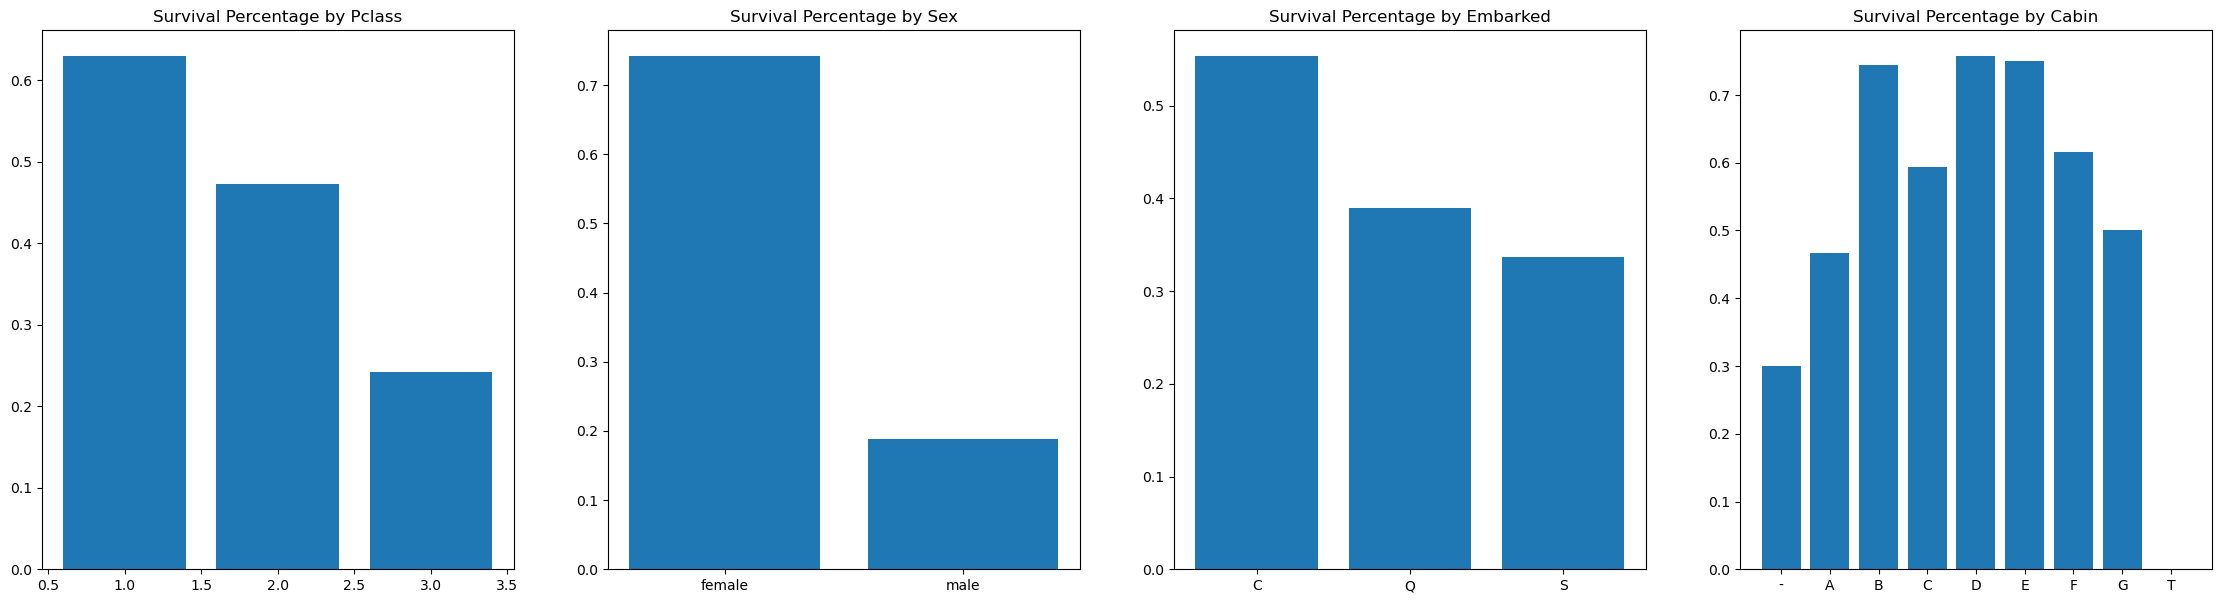

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(28, 7))
ax = ax.flatten()

for idx, col in enumerate(titanic_df_categorical.columns[1:]):
    survival_percentage = (titanic_train[['Survived', col]].groupby([col]).sum() / titanic_train[['Survived', col]].groupby(col).count())
    ax[idx].bar(survival_percentage.index, survival_percentage.values.flatten())
    ax[idx].set_title(f'Survival Percentage by {col}')


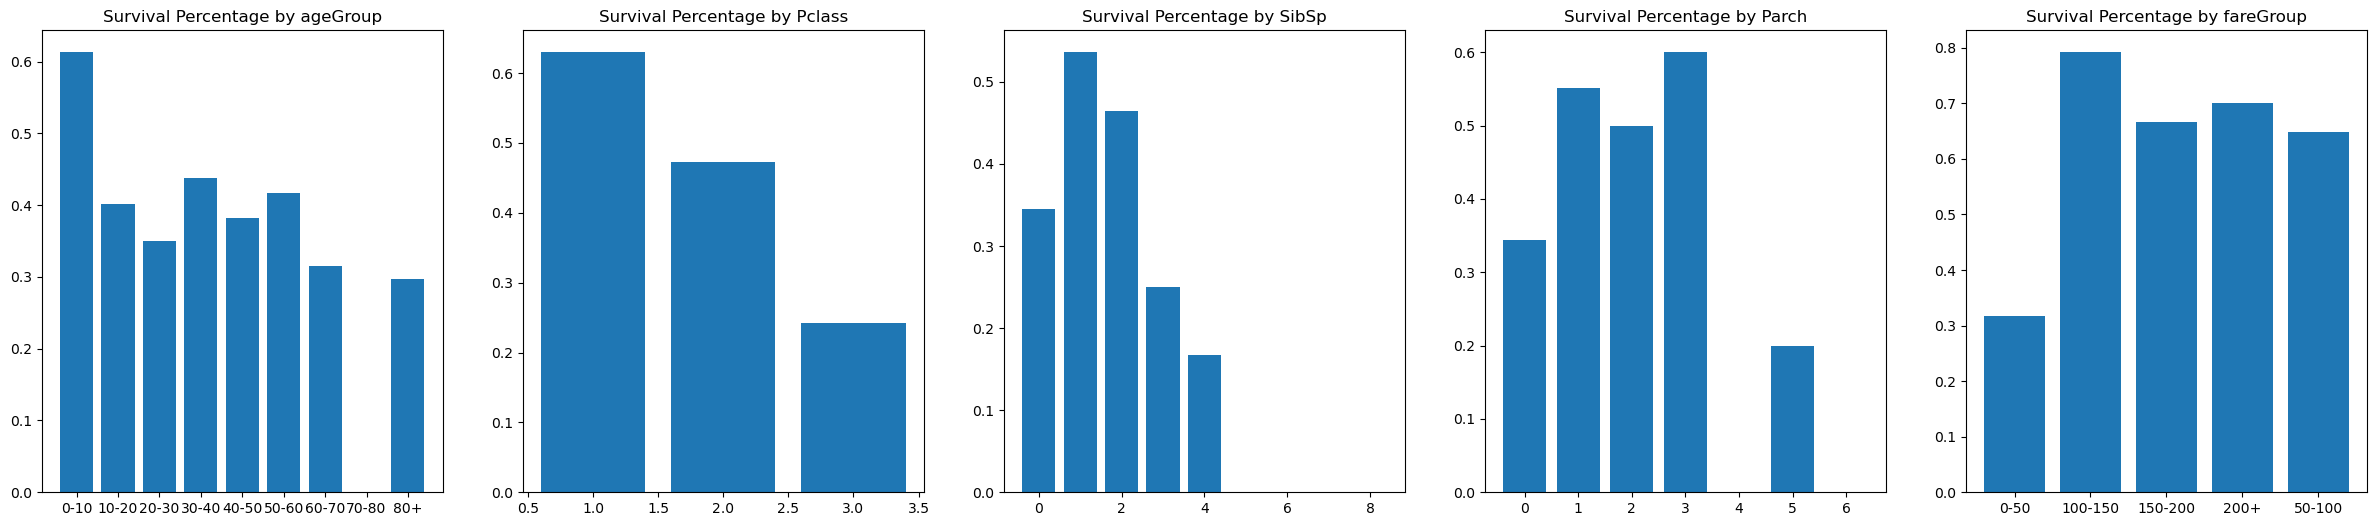

In [9]:
fig, ax = plt.subplots(1, 5, figsize=(30, 6))
ax = ax.flatten()
columns = ['ageGroup', 'Pclass', 'SibSp', 'Parch', 'fareGroup']
for idx, col in enumerate(columns):
    survival_percentage = (titanic_train[['Survived', col]].groupby([col]).sum() / titanic_train[['Survived', col]].groupby(col).count())
    ax[idx].bar(survival_percentage.index, survival_percentage.values.flatten())
    ax[idx].set_title(f'Survival Percentage by {col}')

### Preparing the data

In [10]:
titanic_combined_raw = titanic_combined_raw.round(0)

titanic_combined_raw['ageGroup'] = titanic_combined_raw['Age'].apply(lambda x: age_2_agegroup(x))
titanic_combined_raw['fareGroup'] = titanic_combined_raw['Fare'].apply(lambda x: fare_2_faregroup(x))

titanic_combined = titanic_combined_raw.drop(['PassengerId', 'Name', 'Ticket', 'Age', 'Fare', 'Embarked'], axis=1)

titanic_combined['Cabin'] = titanic_combined['Cabin'].fillna('-')
titanic_combined['Cabin'] = titanic_combined['Cabin'].apply(lambda x: x[0])


titanic_combined_dummies = pd.get_dummies(titanic_combined, columns=['Sex', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'ageGroup', 'fareGroup'], drop_first=True)



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
titanic_combined_dummies= scaler.fit_transform(titanic_combined_dummies)

In [ ]:
Xtrain = titanic_combined_dummies[titanic_combined['train_test'] == 1].drop(['Survived', 'train_test'], axis=1)
Ytrain = titanic_combined_dummies[titanic_combined['train_test'] == 1]['Survived']

Xtest = titanic_combined_dummies[titanic_combined['train_test'] == 0].drop(['Survived', 'train_test'], axis=1)

AttributeError: 'numpy.ndarray' object has no attribute 'drop'

## Model Training
Heavily inspired by https://www.kaggle.com/code/kenjee/titanic-project-example
### Baseline

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 2000)
cv = cross_val_score(lr,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.77653631 0.82022472 0.79213483 0.7752809  0.78089888]
0.7890151277383717


In [ ]:
from sklearn import tree

dt = tree.DecisionTreeClassifier(random_state = 1)
cv = cross_val_score(dt,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.76536313 0.76966292 0.83707865 0.78089888 0.83146067]
0.7968928504174251


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
cv = cross_val_score(knn,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.75418994 0.80898876 0.80337079 0.76404494 0.82022472]
0.7901638315234448


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 1)
cv = cross_val_score(rf,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.75418994 0.79775281 0.83146067 0.75280899 0.83146067]
0.7935346180402988


In [ ]:
from sklearn.svm import SVC

svc = SVC(probability = True)
cv = cross_val_score(svc,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.77653631 0.80898876 0.8258427  0.80337079 0.82022472]
0.8069926558282594


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state =1)
cv = cross_val_score(xgb,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.7877095  0.80337079 0.81460674 0.76404494 0.81460674]
0.79686774213797


In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators = [('lr',lr),('knn',knn),('rf',rf),('svc',svc),('xgb',xgb)], voting = 'soft') 
cv = cross_val_score(voting_clf,Xtrain,Ytrain,cv=5)
print(cv)
print(cv.mean())

[0.77653631 0.81460674 0.83707865 0.7752809  0.8258427 ]
0.8058690603226413


In [ ]:
voting_clf.fit(Xtrain,Ytrain)
y_hat_base_vc = voting_clf.predict(Xtest).astype(int)
basic_submission = {'PassengerId': titanic_raw_test.PassengerId, 'Survived': y_hat_base_vc}
base_submission = pd.DataFrame(data=basic_submission)
base_submission.to_csv('base_submission.csv', index=False)

In [ ]:
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 

In [ ]:
def clf_performance(classifier, model_name):
    print(model_name)
    print('Best Score: ' + str(classifier.best_score_))
    print('Best Parameters: ' + str(classifier.best_params_))

In [ ]:
lr = LogisticRegression()
param_grid = {'max_iter' : [1000, 2000],
              'penalty' : ['l1', 'l2'],
              'C' : np.logspace(-4, 4, 20),
              'solver' : ['liblinear']}

clf_lr = GridSearchCV(lr, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_lr = clf_lr.fit(Xtrain,Ytrain)
clf_performance(best_clf_lr,'Logistic Regression')

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Logistic Regression
Best Score: 0.7957629778419435
Best Parameters: {'C': np.float64(78.47599703514607), 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
knn = KNeighborsClassifier()
param_grid = {'n_neighbors' : [3,5,7,9, 11, 13, 15],
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto', 'ball_tree','kd_tree'],
              'p' : [1,2]}
clf_knn = GridSearchCV(knn, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_knn = clf_knn.fit(Xtrain,Ytrain)
clf_performance(best_clf_knn,'KNN')

Fitting 5 folds for each of 84 candidates, totalling 420 fits
KNN
Best Score: 0.8036407005209968
Best Parameters: {'algorithm': 'kd_tree', 'n_neighbors': 13, 'p': 2, 'weights': 'distance'}


In [ ]:
svc = SVC(probability = True)
param_grid = [  
                {'kernel': ['rbf'],'gamma': ['scale', 'auto', .1,.5,1,2,5,10],'C': [.1, 1, 10, 100, 1000]},
                {'kernel': ['linear'], 'gamma': ['scale', 'auto', .1,.5,1,2,5,10], 'C': [.1, 1, 10, 100, 1000]},
                {'kernel': ['poly'], 'degree' : [2,3,4,5, 10], 'C': [.1, 1, 10, 100, 1000]}, 
                {'kernel': ['sigmoid'], 'gamma': ['scale', 'auto', .1,.5,1,2,5,10], 'C': [.1, 1, 10, 100, 1000]},
            ]
clf_svc = GridSearchCV(svc, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_svc = clf_svc.fit(Xtrain,Ytrain)
clf_performance(best_clf_svc,'SVC')

Fitting 5 folds for each of 145 candidates, totalling 725 fits
SVC
Best Score: 0.818209779674848
Best Parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [50,100,500,1000], 
                                  'bootstrap': [True,False],
                                  'max_depth': [3,5,10,20,50,75,100,None],
                                  'max_features': ['log2', 'sqrt'],
                                  'min_samples_leaf': [1,2,4,10],
                                  'min_samples_split': [2,5,10]}
                                  
clf_rf_rnd = RandomizedSearchCV(rf, param_distributions = param_grid, n_iter = 100, cv = 5, verbose = True, n_jobs = -1)
best_clf_rf_rnd = clf_rf_rnd.fit(Xtrain,Ytrain)
clf_performance(best_clf_rf_rnd,'Random Forest')

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Random Forest
Best Score: 0.7957818090515347
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [ ]:
rf = RandomForestClassifier(random_state = 1)
param_grid =  {'n_estimators': [60,70,80,90,100,110,120,130,140],
               'criterion':['gini','entropy'],
                                  'bootstrap': [True],
                                  'max_depth': [15, 20, 25],
                                  'max_features': ['log2', 'sqrt', 10, 20, 30],
                                  'min_samples_leaf': [2,3,4,5],
                                  'min_samples_split': [2,3,4,5]}
                                  
clf_rf = GridSearchCV(rf, param_grid = param_grid, cv = 5, verbose = True, n_jobs = 6)
best_clf_rf = clf_rf.fit(Xtrain,Ytrain)
clf_performance(best_clf_rf,'Random Forest')

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Random Forest
Best Score: 0.8069612704789405
Best Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 20, 'max_features': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}


In [ ]:
xgb = XGBClassifier(random_state = 1)

param_grid = {
    'n_estimators': [20, 50, 100, 250, 500,1000],
    'colsample_bytree': [0.2, 0.5, 0.7, 0.8, 1],
    'max_depth': [2, 5, 10, 15, 20, 25, None],
    'reg_alpha': [0, 0.5, 1],
    'reg_lambda': [1, 1.5, 2],
    'subsample': [0.5,0.6,0.7, 0.8, 0.9],
    'learning_rate':[.01,0.1,0.2,0.3,0.5, 0.7, 0.9],
    'gamma':[0,.01,.1,1,10,100],
    'min_child_weight':[0,.01,0.1,1,10,100],
}


clf_xgb_rnd = RandomizedSearchCV(xgb, param_distributions = param_grid, n_iter = 1000, cv = 5, verbose = True, n_jobs = 6)
best_clf_xgb_rnd = clf_xgb_rnd.fit(Xtrain,Ytrain)
clf_performance(best_clf_xgb_rnd,'XGB')

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
XGB
Best Score: 0.8193208210407382
Best Parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 50, 'min_child_weight': 0.01, 'max_depth': 25, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [ ]:
xgb = XGBClassifier(random_state = 1)

param_grid = {
    'n_estimators': [35,50,65],
    'colsample_bytree': [0.75,0.8,0.85],
    'max_depth': [10, 15, 25, None],
    'reg_alpha': [0.5],
    'reg_lambda': [1, 2],
    'subsample': [0.5,  0.7,  0.9],
    'learning_rate':[0.1, 0.5],
    'gamma':[0.1, 0.5],
    'min_child_weight':[0.01],
    'sampling_method': ['uniform']
}

clf_xgb = GridSearchCV(xgb, param_grid = param_grid, cv = 5, verbose = True, n_jobs = -1)
best_clf_xgb = clf_xgb.fit(Xtrain,Ytrain)
clf_performance(best_clf_xgb,'XGB')

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


XGB
Best Score: 0.8204444165463561
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 15, 'min_child_weight': 0.01, 'n_estimators': 50, 'reg_alpha': 0.5, 'reg_lambda': 1, 'sampling_method': 'uniform', 'subsample': 0.9}


In [ ]:
y_hat_xgb = best_clf_xgb.best_estimator_.predict(Xtest).astype(int)
xgb_submission = {'PassengerId': titanic_raw_test.PassengerId, 'Survived': y_hat_xgb}
submission_xgb = pd.DataFrame(data=xgb_submission)
submission_xgb.to_csv('xgb_submission.csv', index=False)

In [ ]:
best_lr = best_clf_lr.best_estimator_
best_knn = best_clf_knn.best_estimator_
best_svc = best_clf_svc.best_estimator_
best_rf = best_clf_rf.best_estimator_
best_xgb = best_clf_xgb.best_estimator_

voting_clf_hard = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'hard') 
voting_clf_soft = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc)], voting = 'soft') 
voting_clf_all = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc), ('lr', best_lr)], voting = 'soft') 
voting_clf_xgb = VotingClassifier(estimators = [('knn',best_knn),('rf',best_rf),('svc',best_svc), ('xgb', best_xgb),('lr', best_lr)], voting = 'soft')

print('voting_clf_hard :',cross_val_score(voting_clf_hard,Xtrain,Ytrain,cv=5))
print('voting_clf_hard mean :',cross_val_score(voting_clf_hard,Xtrain,Ytrain,cv=5).mean())

print('voting_clf_soft :',cross_val_score(voting_clf_soft,Xtrain,Ytrain,cv=5))
print('voting_clf_soft mean :',cross_val_score(voting_clf_soft,Xtrain,Ytrain,cv=5).mean())

print('voting_clf_all :',cross_val_score(voting_clf_all,Xtrain,Ytrain,cv=5))
print('voting_clf_all mean :',cross_val_score(voting_clf_all,Xtrain,Ytrain,cv=5).mean())

print('voting_clf_xgb :',cross_val_score(voting_clf_xgb,Xtrain,Ytrain,cv=5))
print('voting_clf_xgb mean :',cross_val_score(voting_clf_xgb,Xtrain,Ytrain,cv=5).mean())

voting_clf_hard : [0.79888268 0.80337079 0.83707865 0.78651685 0.84269663]
voting_clf_hard mean : 0.813709120582512
voting_clf_soft : [0.7877095  0.78651685 0.84269663 0.78651685 0.84269663]
voting_clf_soft mean : 0.8103508882053857
voting_clf_all : [0.79329609 0.80337079 0.83707865 0.80337079 0.83707865]
voting_clf_all mean : 0.8148389931579938
voting_clf_xgb : [0.79888268 0.80337079 0.84269663 0.80337079 0.83146067]
voting_clf_xgb mean : 0.815956311593748


In [ ]:
params = {'weights' : [[1,1,1,1,1],[1,1,1,1,2],[1,1,1,2,1],[1,1,2,1,1],[1,2,1,1,1],[2,1,1,1,1],[2,1,2,1,1]]}

vote_weight = GridSearchCV(voting_clf_xgb, param_grid = params, cv = 5, verbose = True, n_jobs = -1)
best_clf_weight = vote_weight.fit(Xtrain,Ytrain)
clf_performance(best_clf_weight,'VC Weights')


Fitting 5 folds for each of 7 candidates, totalling 35 fits
VC Weights
Best Score: 0.819327098110602
Best Parameters: {'weights': [1, 1, 2, 1, 1]}


In [ ]:
y_hat_voting = best_clf_weight.best_estimator_.predict(Xtest).astype(int)
voting_submission = {'PassengerId': titanic_raw_test.PassengerId, 'Survived': y_hat_voting}
submission_xgb = pd.DataFrame(data=voting_submission)
submission_xgb.to_csv('voting_submission.csv', index=False)